# Project 1: Numerical Methods for ODEs #
**Eric Del Toro**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Introduction

In this project we seek to investgiate the performance of several numerical methods in solving initial value problems/ordinary differential equations. These various methods represent a range of orders of accuracy and one-step/multistep approaches. Each problem entails numerical approximations for each method, and comparisons with exact solutions via plots and error analysis, taking consideration of factors like step size.

## Problem A: Smooth Test Problem
We consider the following smooth test problem:
$$y = y-t^2+1,  0 \le t \le 2,  y(0) = 0.5.$$

With the exact solution: $$y(t) = (t+1)^2 - \frac{1}{2}e^t.$$

In [2]:
def f(t, y):
    return y - t**2 + 1
def exact(t):
    return (t+1)**2 - 0.5*np.exp(t)

t0 = 0
T = 2
y0 = 0.5

### Method Definitions

#### Euler Method
An explicit, first-order method which approximates the solution using the slope at the beginning of each interval (and assumes a tangential continuation of that slope for the given step size). Given by:

$$ w_{n+1} = w_n + h, f(t_n, w_n). $$

In [3]:
def euler(f, t0, y0, T, h):
    n = int((T-t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        w[i+1] = w[i] + h*f(t[i], w[i])

    return t, w

#### Midpoint Method
A second-order RK-derivative method which improves on the accuracy of the Euler method by taking the slope evaluated at the middle of a given time interval rather than beginning. Given by:
$$ k_1 = f(t_n, w_n), $$
$$ k_2 = f(t_n+\frac{h}{2}, w_n + \frac{h}{2}k_1), $$
$$ w_{n+1} = w_n + h, k_2 . $$

In [4]:
def midpoint(f, t0, y0, T, h):
    n = int((T-t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)
    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        k1 = f(t[i], w[i])
        k2 = f(t[i] + h/2, w[i] + h*k1/2)
        w[i+1] = w[i] + h*k2

    return t, w

#### Heun Method
Another second-order RK method which takes slope evaluations at the beginning and end of the time interval and utilizes an average of the two. 
$$ k_1 = f(t_n, w_n), $$
$$ k_2 = f(t_n+h, w_n+h, k_1), $$
$$ w_n + \frac{h}{2}(k_1+k_2). $$

In [5]:
def heun(f, t0, y0, T, h):
    n = int((T-t0) / h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0
    for i in range(n):
        t[i+1] = t[i] + h
        k1 = f(t[i], w[i])
        k2 = f(t[i] + h, w[i] + h*k1)

        w[i+1] = w[i] + h*(k1 + k2)/2
    return t, w

#### RK4 Method
The classical fourth-order Runge-Kutta method computes approximations via a more complex weighted average of four slope evaluations (k values) in each step. Computationally complex but greatly improved in accuracy.
$$ k_1=f(t_n,w_n), $$
$$ k_2=f(t_n+\frac{h}{2}, w_n+\frac{h}{2}k_1), $$
$$ k_3 = f(t_n+\frac{h}{2}, w_n + \frac{h}{2}k_2), $$
$$ k_4 = f(t_n+h, w_n+h +hk+3). $$
With updates according to: $ w_n + \frac{h}{6}(k_1+2k_2+2k_3+k_4). $

In [6]:
def rk4(f, t0, y0, T, h):
    n = int((T-t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        k1 = f(t[i], w[i])
        k2 = f(t[i] + h/2, w[i] + h*k1/2)
        k3 = f(t[i] + h/2, w[i] + h*k2/2)
        k4 = f(t[i] + h, w[i] + h*k3)

        w[i+1] = w[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
        
    return t,w

#### Second-Order Taylor Method
Improves upon more simplistic methods like Euler's by utilizing the first and second derivative of the initial value problem to more closely follow the curvature of more complicated solutions. Given by:
$$ w_n + h, y'(t_n) + \frac{h^2}{2}y''(t_n). $$

In [7]:
def taylor2(t0, y0, T, h):
    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        yp = w[i] - t[i]**2 + 1
        ypp = w[i] - t[i]**2 + 1 - 2*t[i]
        w[i+1] = w[i] + h*yp + (h**2/2)*ypp

    return t,w

#### Adams-Bashforth & Adams-Moulton Method
The second-order Adams methods are explicit and implicit, respectively. The AB method uses derivative information from prior mesh points, reducing the number of necessary function evaluations from initiation as the approximation progresses. The AM method uses solution values from both the current and future iterations, approximating future unknowns with each step, and exhibits improved stability over AB given its implicit status. 

AB: $w_{n+1} = w_n + \frac{h}{2}[3f(t_n, w_n) - f(t_{n-1}, w_{n-1})].$

AM: $w_{n+1} = w_n + \frac{h}{2}[f(t_{n+1}, w_{n+1}) + f(t_n, w_n)].$

In [8]:
def adams_bashforth(f, t0, y0, T, h):
    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    k1 = f(t0, y0)
    k2 = f(t0+h/2, y0+h*k1/2)
    k3 = f(t0+h/2, y0+h*k2/2)
    k4 = f(t0+h, y0+h*k3)

    t[1] = t0+h
    w[1] = y0 + h*(k1+2*k2+2*k3+k4)/6

    for i in range(1,n):
        t[i+1] = t[i] + h
        fn = f(t[i],w[i])
        fnm1 = f(t[i-1],w[i-1])
        w[i+1] = w[i] + h*(3*fn-fnm1)/2

    return t,w

In [9]:
def adams_moulton(f, t0, y0, T, h, iterations=5):

    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    k1 = f(t0, y0)
    k2 = f(t0+h/2, y0+h*k1/2)
    k3 = f(t0+h/2, y0+h*k2/2)
    k4 = f(t0+h, y0+h*k3)

    t[1] = t0 + h
    w[1] = y0 + h*(k1 + 2*k2 + 2*k3 + k4)/6

    for i in range(1, n):
        t[i+1] = t[i] + h
        w_guess = w[i] + h*(3*f(t[i], w[i]) - f(t[i-1], w[i-1]))/2

        for j in range(iterations):
            w_guess = w[i] + h*(f(t[i+1], w_guess) + f(t[i], w[i]))/2
        w[i+1] = w_guess

    return t, w

#### Predictor-Corrector Method
Combines the AB method with AM correction. 

In [10]:
def predictor_corrector(f, t0, y0, T, h):
    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    k1 = f(t0, y0)
    k2 = f(t0+h/2, y0+h*k1/2)
    k3 = f(t0+h/2, y0+h*k2/2)
    k4 = f(t0+h, y0+h*k3)

    t[1] = t0 + h
    w[1] = y0 + h*(k1 + 2*k2 + 2*k3 + k4)/6

    for i in range(1, n):
        t[i+1] = t[i] + h
        w_predict = w[i] + h*(3*f(t[i], w[i]) - f(t[i-1], w[i-1]))/2
        
        w[i+1] = w[i] + h*(f(t[i+1], w_predict) + f(t[i], w[i]))/2

    return t, w

### Exact vs. Numerical Solutions

In [11]:
## Implementation
h=0.2

t_eu, w_eu = euler(f, t0, y0, T, h)
t_mid, w_mid = midpoint(f, t0, y0, T, h)
t_heun, w_heun = heun(f, t0, y0, T, h)
t_rk4, w_rk4 = rk4(f, t0, y0, T, h)
t_tay, w_tay = taylor2(t0, y0, T, h)
t_ab, w_ab = adams_bashforth(f, t0, y0, T, h)
t_am, w_am = adams_moulton(f, t0, y0, T, h)
t_pc, w_pc = predictor_corrector(f, t0, y0, T, h)

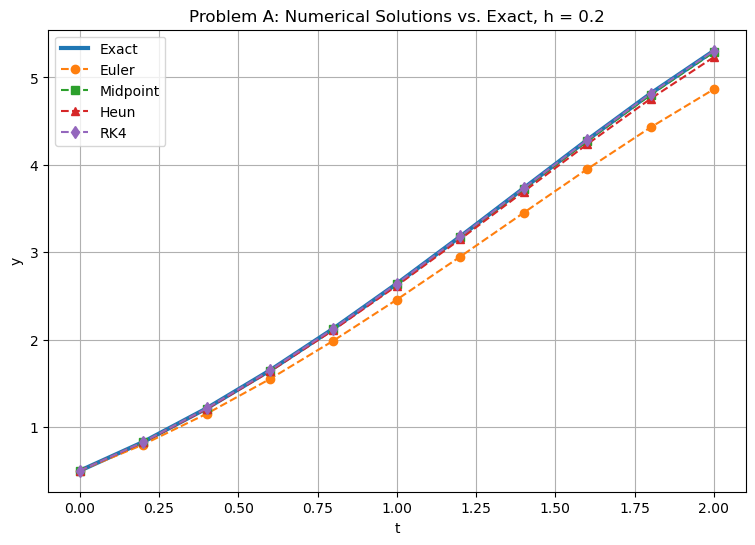

In [12]:
## Plotting
plt.figure(figsize=(9, 6))

plt.plot(t_eu, exact(t_eu), label="Exact", linewidth=3)
plt.plot(t_eu, w_eu, "o--", label="Euler")
plt.plot(t_mid, w_mid, "s--", label="Midpoint")
plt.plot(t_heun, w_heun, "^--", label="Heun")
plt.plot(t_rk4, w_rk4, "d--", label="RK4")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem A: Numerical Solutions vs. Exact, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

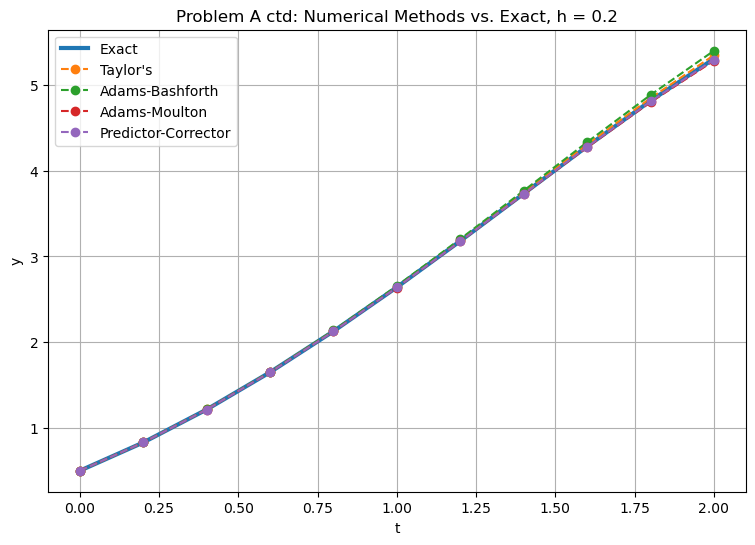

In [13]:
plt.figure(figsize=(9,6))
plt.plot(t_eu, exact(t_eu), linewidth=3, label="Exact")
plt.plot(t_tay, w_tay, "o--", label="Taylor's")
plt.plot(t_ab, w_ab, "o--", label="Adams-Bashforth")
plt.plot(t_am, w_am, "o--", label="Adams-Moulton")
plt.plot(t_pc, w_pc,"o--", label="Predictor-Corrector")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem A ctd: Numerical Methods vs. Exact, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

### Error Computation & Plots

In [14]:
def abs_error(exact, numerical):
    return np.abs(exact-numerical)
def max_error(exact, numerical):
    return np.max(np.abs(exact-numerical))

In [15]:
err_eu = abs_error(exact(t_eu), w_eu)
err_tay = abs_error(exact(t_tay), w_tay)
err_mid = abs_error(exact(t_mid), w_mid)
err_heun = abs_error(exact(t_heun), w_heun)
err_rk4 = abs_error(exact(t_rk4), w_rk4)
err_ab = abs_error(exact(t_ab), w_ab)
err_am = abs_error(exact(t_am), w_am)
err_pc = abs_error(exact(t_pc), w_pc)

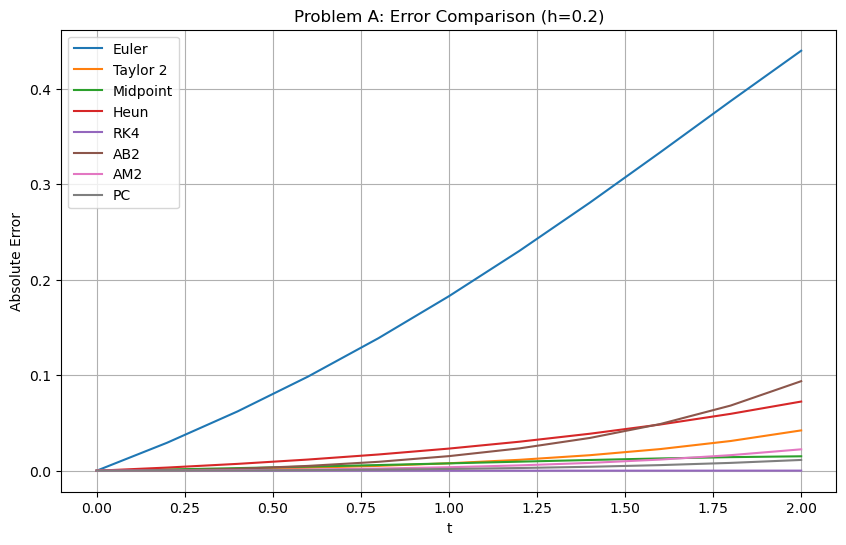

In [16]:
## Plotting
plt.figure(figsize=(10,6))

plt.plot(t_eu, err_eu, label='Euler')
plt.plot(t_tay, err_tay, label='Taylor 2')
plt.plot(t_mid, err_mid, label='Midpoint')
plt.plot(t_heun, err_heun, label='Heun')
plt.plot(t_rk4, err_rk4, label='RK4')
plt.plot(t_ab, err_ab, label='AB2')
plt.plot(t_am, err_am, label='AM2')
plt.plot(t_pc, err_pc, label='PC')

plt.xlabel('t')
plt.ylabel('Absolute Error')
plt.title('Problem A: Error Comparison (h=0.2)')
plt.legend()
plt.grid(True)
plt.show()

#### Maximum Error Table

In [17]:
h_values = [0.2, 0.1, 0.05]

methods = [
    ("Euler", euler),
    ("Taylor", taylor2),
    ("Midpoint", midpoint),
    ("Heun", heun),
    ("RK4", rk4),
    ("AB2", adams_bashforth),
    ("AM2", adams_moulton),
    ("Predictor-Corrector", predictor_corrector)
]

print(f"{'Method':<22} {'h = 0.2':>15} {'h = 0.1':>15} {'h = 0.05':>15}")
print("-" * 70)

for method_name, method in methods:
    row = f"{method_name:<22}"

    for h in h_values:
        if method_name == "Taylor":
            t, w = method(t0, y0, T, h)
        else:
            t, w = method(f, t0, y0, T, h)

        exact_values = exact(t)
        error = np.abs(exact_values - w)
        max_err = np.max(error)

        row += f"{max_err:15.6e}"

    print(row)

Method                         h = 0.2         h = 0.1        h = 0.05
----------------------------------------------------------------------
Euler                    4.396874e-01   2.419719e-01   1.274657e-01
Taylor                   4.221234e-02   1.141063e-02   2.964437e-03
Midpoint                 1.510249e-02   3.747074e-03   9.277142e-04
Heun                     7.241732e-02   1.890478e-02   4.819865e-03
RK4                      1.089498e-04   6.990307e-06   4.421339e-07
AB2                      9.373255e-02   2.718050e-02   7.257185e-03
AM2                      2.239965e-02   5.864208e-03   1.501807e-03
Predictor-Corrector      1.127415e-02   4.266544e-03   1.287299e-03


### Point Numerical Approximation Comparison (Euler & RK4)

Using step size h=0.1, we compare evaluations for absolute error between the method which demonstrated the least accuracy (Euler) and the most (RK4).

**Euler Method**

In [18]:
print()
print(f"{'t':<8}{'Exact':<15}{'Euler':<15}{'Absolute Error':<15}")
print("-"*55)

for i in range(len(t_eu)):
    print(
        f"{t_eu[i]:<8.2f}"
        f"{exact(t_eu)[i]:<15.6f}"
        f"{w_eu[i]:<15.6f}"
        f"{err_eu[i]:<15.6e}"
    )


t       Exact          Euler          Absolute Error 
-------------------------------------------------------
0.00    0.500000       0.500000       0.000000e+00   
0.20    0.829299       0.800000       2.929862e-02   
0.40    1.214088       1.152000       6.208765e-02   
0.60    1.648941       1.550400       9.854060e-02   
0.80    2.127230       1.988480       1.387495e-01   
1.00    2.640859       2.458176       1.826831e-01   
1.20    3.179942       2.949811       2.301303e-01   
1.40    3.732400       3.451773       2.806266e-01   
1.60    4.283484       3.950128       3.333557e-01   
1.80    4.815176       4.428154       3.870225e-01   
2.00    5.305472       4.865785       4.396874e-01   


**RK4 Method**

In [19]:
print(f"{'t':<8}{'Exact':<15}{'RK4':<15}{'Abs Error':<15}")
print("-"*55)

for i in range(len(t_rk4)):
    print(
        f"{t_rk4[i]:<8.2f}"
        f"{exact(t_rk4)[i]:<15.6f}"
        f"{w_rk4[i]:<15.6f}"
        f"{err_rk4[i]:<15.6e}"
    )

t       Exact          RK4            Abs Error      
-------------------------------------------------------
0.00    0.500000       0.500000       0.000000e+00   
0.20    0.829299       0.829293       5.287587e-06   
0.40    1.214088       1.214076       1.144051e-05   
0.60    1.648941       1.648922       1.858276e-05   
0.80    2.127230       2.127203       2.685081e-05   
1.00    2.640859       2.640823       3.639304e-05   
1.20    3.179942       3.179894       4.736840e-05   
1.40    3.732400       3.732340       5.994372e-05   
1.60    4.283484       4.283409       7.428948e-05   
1.80    4.815176       4.815086       9.057321e-05   
2.00    5.305472       5.305363       1.089498e-04   


#### Discussion of Results
Serving as a smooth benchmark problem, the exact solution in Part A is fairly simple and all methods demonstrate an ability to follow the solution fairly well. As the interval progresses Euler's method notably deviates the most. The maximum error table demonstrates that every method sees a decrease in error size, with Euler's starting the largest and RK4 the smallest. From h=0.2 to h=0.05 it can be seen that RK4's error decreases very rapidly, down to an order of $10^{-7}$, significantly ahead of all other methods. The other second-order methods perform consistently with each other and theoretical expectations. The mesh point comparison tables at the end further illustrate the difference in accuracy produced by method order/complexity of computation. RK4 demonstrates very minimal increase in error size as the integration interval progresses; it's more computationally complex approach of taking four evaluations per interval clearly leads to reduced local truncation error and lesser accumulated global over compared to a simpler method like Euler's.

# Problem B: Error Amplification Problem

We consider the following error amplification problem: $$y' = 2y, 0 \le t \le 2, y(0) = 1.$$

With the exact solution: $$y(t) = e^{2t}.$$

In [20]:
def fB(t, y):
    return 2*y
def exactB(t):
    return np.exp(2*t)

t0_B = 0
T_B = 2
y0_B = 1

In [21]:
def taylor2_B(t0, y0, T, h):
    n = int((T - t0)/h)

    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h

        yp = 2*w[i]
        ypp = 4*w[i]

        w[i+1] = w[i] + h*yp + (h**2/2)*ypp

    return t, w

In [22]:
h = 0.2

t_eu_B, w_eu_B = euler(fB, t0_B, y0_B, T_B, h)
t_mid_B, w_mid_B = midpoint(fB, t0_B, y0_B, T_B, h)
t_heun_B, w_heun_B = heun(fB, t0_B, y0_B, T_B, h)
t_rk4_B, w_rk4_B = rk4(fB, t0_B, y0_B, T_B, h)

t_tay_B, w_tay_B = taylor2_B(t0_B, y0_B, T_B, h)
t_ab_B, w_ab_B = adams_bashforth(fB, t0_B, y0_B, T_B, h)
t_am_B, w_am_B = adams_moulton(fB, t0_B, y0_B, T_B, h)
t_pc_B, w_pc_B = predictor_corrector(fB, t0_B, y0_B, T_B, h)

### Numerical Solutions

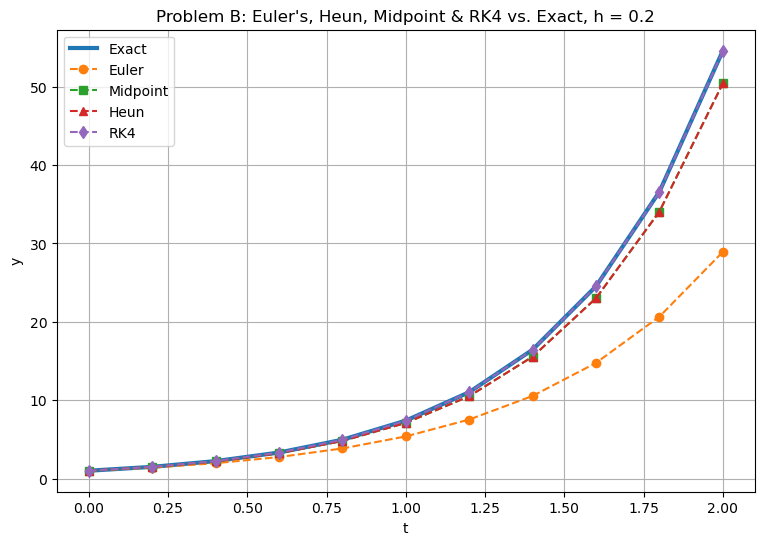

In [23]:
plt.figure(figsize=(9,6))

plt.plot(t_eu_B, exactB(t_eu_B), label="Exact", linewidth=3)
plt.plot(t_eu_B, w_eu_B, "o--", label="Euler")
plt.plot(t_mid_B, w_mid_B, "s--", label="Midpoint")
plt.plot(t_heun_B, w_heun_B, "^--", label="Heun")
plt.plot(t_rk4_B, w_rk4_B, "d--", label="RK4")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem B: Euler's, Heun, Midpoint & RK4 vs. Exact, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

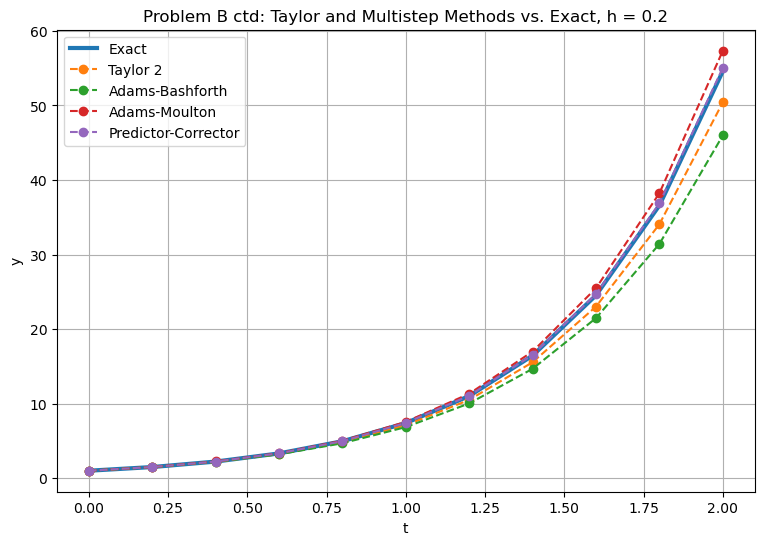

In [24]:
plt.figure(figsize=(9,6))

plt.plot(t_eu_B, exactB(t_eu_B), label="Exact", linewidth=3)
plt.plot(t_tay_B, w_tay_B, "o--", label="Taylor 2")
plt.plot(t_ab_B, w_ab_B, "o--", label="Adams-Bashforth")
plt.plot(t_am_B, w_am_B, "o--", label="Adams-Moulton")
plt.plot(t_pc_B, w_pc_B, "o--", label="Predictor-Corrector")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem B ctd: Taylor and Multistep Methods vs. Exact, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

### Errors

In [25]:
err_eu_B = np.abs(exactB(t_eu_B) - w_eu_B)
err_tay_B = np.abs(exactB(t_tay_B) - w_tay_B)
err_mid_B = np.abs(exactB(t_mid_B) - w_mid_B)
err_heun_B = np.abs(exactB(t_heun_B) - w_heun_B)
err_rk4_B = np.abs(exactB(t_rk4_B) - w_rk4_B)
err_ab_B = np.abs(exactB(t_ab_B) - w_ab_B)
err_am_B = np.abs(exactB(t_am_B) - w_am_B)
err_pc_B = np.abs(exactB(t_pc_B) - w_pc_B)

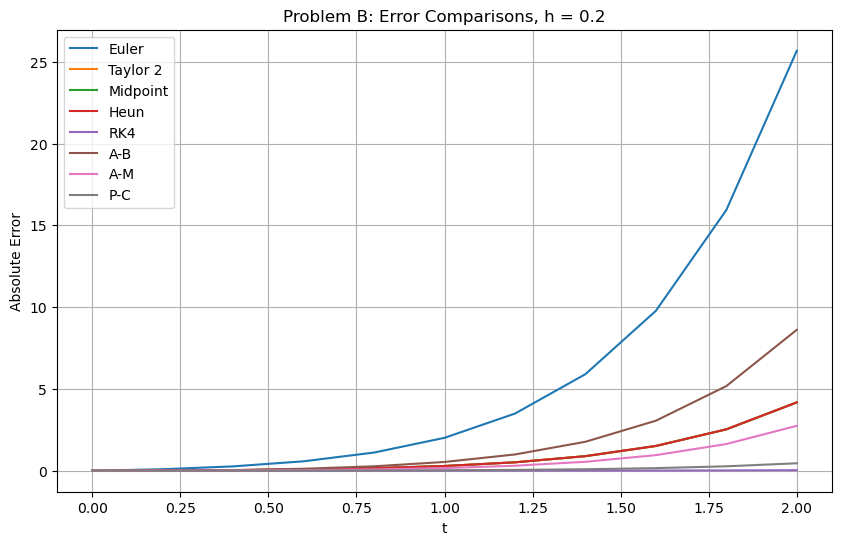

In [26]:
plt.figure(figsize=(10,6))

plt.plot(t_eu_B, err_eu_B, label="Euler")
plt.plot(t_tay_B, err_tay_B, label="Taylor 2")
plt.plot(t_mid_B, err_mid_B, label="Midpoint")
plt.plot(t_heun_B, err_heun_B, label="Heun")
plt.plot(t_rk4_B, err_rk4_B, label="RK4")
plt.plot(t_ab_B, err_ab_B, label="A-B")
plt.plot(t_am_B, err_am_B, label="A-M")
plt.plot(t_pc_B, err_pc_B, label="P-C")

plt.xlabel("t")
plt.ylabel("Absolute Error")
plt.title("Problem B: Error Comparisons, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

**Maximum Error Table**

In [27]:
h_values = [0.2, 0.1, 0.05]

methods_B = [
    ("Euler", euler),
    ("Taylor", taylor2_B),
    ("Midpoint", midpoint),
    ("Heun", heun),
    ("RK4", rk4),
    ("A-B", adams_bashforth),
    ("A-M", adams_moulton),
    ("P-C", predictor_corrector)
]

print(f"{'Method':<22} {'h = 0.2':>15} {'h = 0.1':>15} {'h = 0.05':>15}")
print("-" * 70)

for method_name, method in methods_B:
    row = f"{method_name:<22}"

    for h in h_values:
        if method_name == "Taylor":
            t, w = method(t0_B, y0_B, T_B, h)
        else:
            t, w = method(fB, t0_B, y0_B, T_B, h)

        exact_values = exactB(t)
        error = np.abs(exact_values - w)
        max_err = np.max(error)

        row += f"{max_err:15.6e}"

    print(row)

Method                         h = 0.2         h = 0.1        h = 0.05
----------------------------------------------------------------------
Euler                    2.567268e+01   1.626055e+01   9.338894e+00
Taylor                   4.176488e+00   1.240510e+00   3.367343e-01
Midpoint                 4.176488e+00   1.240510e+00   3.367343e-01
Heun                     4.176488e+00   1.240510e+00   3.367343e-01
RK4                      3.342851e-02   2.465808e-03   1.674589e-04
A-B                      8.613865e+00   2.896192e+00   8.222824e-01
A-M                      2.745411e+00   7.000482e-01   1.779957e-01
P-C                      4.543269e-01   3.513330e-01   1.294693e-01


### Comparing Numerical Approximations & Abs Error (Euler & RK4)
**Euler's Method**

In [28]:

print(f"{'t':<8}{'Exact':<15}{'Euler':<15}{'Absolute Error':<15}")
print("-"*60)

for i in range(len(t_eu_B)):
    print(
        f"{t_eu_B[i]:<8.2f}"
        f"{exactB(t_eu_B)[i]:<15.6f}"
        f"{w_eu_B[i]:<15.6f}"
        f"{err_eu_B[i]:<15.6e}"
    )

t       Exact          Euler          Absolute Error 
------------------------------------------------------------
0.00    1.000000       1.000000       0.000000e+00   
0.20    1.491825       1.400000       9.182470e-02   
0.40    2.225541       1.960000       2.655409e-01   
0.60    3.320117       2.744000       5.761169e-01   
0.80    4.953032       3.841600       1.111432e+00   
1.00    7.389056       5.378240       2.010816e+00   
1.20    11.023176      7.529536       3.493640e+00   
1.40    16.444647      10.541350      5.903296e+00   
1.60    24.532530      14.757891      9.774640e+00   
1.80    36.598234      20.661047      1.593719e+01   
2.00    54.598150      28.925465      2.567268e+01   


**RK4 Method**

In [29]:

print(f"{'t':<8}{'Exact':<15}{'RK4':<15}{'Absolute Error':<15}")
print("-"*60)

for i in range(len(t_rk4_B)):
    print(
        f"{t_rk4_B[i]:<8.2f}"
        f"{exactB(t_rk4_B)[i]:<15.6f}"
        f"{w_rk4_B[i]:<15.6f}"
        f"{err_rk4_B[i]:<15.6e}"
    )

t       Exact          RK4            Absolute Error 
------------------------------------------------------------
0.00    1.000000       1.000000       0.000000e+00   
0.20    1.491825       1.491733       9.136431e-05   
0.40    2.225541       2.225268       2.725907e-04   
0.60    3.320117       3.319507       6.099677e-04   
0.80    4.953032       4.951819       1.213249e-03   
1.00    7.389056       7.386794       2.262375e-03   
1.20    11.023176      11.019126      4.049956e-03   
1.40    16.444647      16.437598      7.048579e-03   
1.60    24.532530      24.520513      1.201705e-02   
1.80    36.598234      36.578067      2.016764e-02   
2.00    54.598150      54.564722      3.342851e-02   


#### Discussion of Results

Stepping up from problem A, problem B's solution exhibits less simplistic exponential growth. The methods still perform fairly well at following the growth of the exact solution, but the differences become more pronounced over the course of the interval due to the accumulation of small errors over the course of the respective approximations. Again, Euler's exhibits the most significant deviation, as shown by the exponential growth in absolute error plotted above. Adams-Bashforth and Heun in particular show less pronounced but similar trajectories, though all second-order methods peform intermediately. Again a comparison of absolute error via tables between Euler's and RK4 show that Euler's error increases dramatically, reaching approximately 25.67 by t=2.0. Comparatively RK4 remains quite small at 0.03343. The results demonstrate that the behavior of the equation in question is highly influential on the efficacy of approximation methods, with the exponential nature of the solution in problem B leading to error propagation being a more pronounced problem, demanding higher-order methods.

# Problem C: Rapid Decay

We a consider the following self selected problem: $$y' = -10y, 0 \le t \le 2, y(0) = 1.$$

With the exact solution: $$y(t) = e^{-10t}.$$

I chose this problem because the exact solution exhibits rapid decay towards zero as t increases. As demonstrated in the previous problem there may be interesting behaviors to observe as the various methods attempt to follow the decay of the solution, depending also of course on step size. 

In [30]:
def fC(t, y):
    return -10*y

def exactC(t):
    return np.exp(-10*t)

t0_C = 0
T_C = 2
y0_C = 1

In [31]:
def taylor2_C(t0, y0, T, h):
    n = int((T - t0)/h)
    t = np.zeros(n+1)
    w = np.zeros(n+1)

    t[0] = t0
    w[0] = y0

    for i in range(n):
        t[i+1] = t[i] + h
        yp = -10*w[i]
        ypp = 100*w[i]
        w[i+1] = w[i] + h*yp + (h**2/2)*ypp

    return t, w

In [32]:
h = 0.2

t_eu_C, w_eu_C = euler(fC, t0_C, y0_C, T_C, h)
t_mid_C, w_mid_C = midpoint(fC, t0_C, y0_C, T_C, h)
t_heun_C, w_heun_C = heun(fC, t0_C, y0_C, T_C, h)
t_rk4_C, w_rk4_C = rk4(fC, t0_C, y0_C, T_C, h)

t_tay_C, w_tay_C = taylor2_C(t0_C, y0_C, T_C, h)
t_ab_C, w_ab_C = adams_bashforth(fC, t0_C, y0_C, T_C, h)
t_am_C, w_am_C = adams_moulton(fC, t0_C, y0_C, T_C, h)
t_pc_C, w_pc_C = predictor_corrector(fC, t0_C, y0_C, T_C, h)

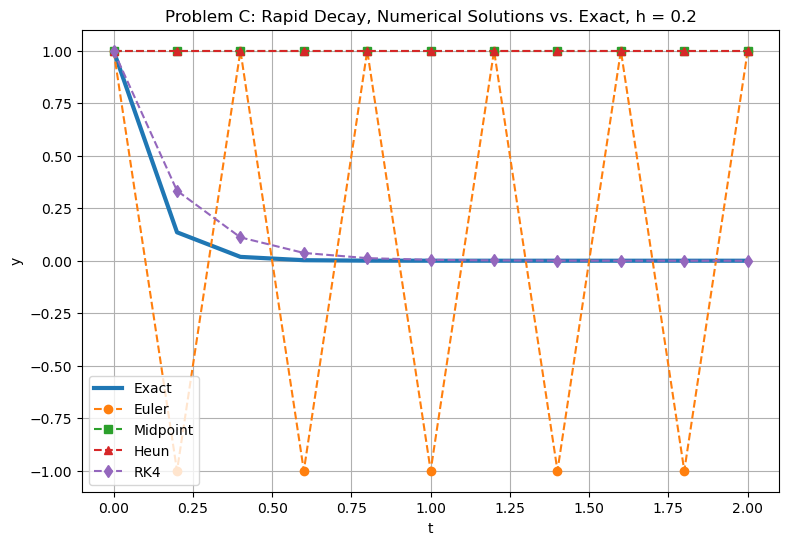

In [33]:
plt.figure(figsize=(9,6))

plt.plot(t_eu_C, exactC(t_eu_C), label="Exact", linewidth=3)
plt.plot(t_eu_C, w_eu_C, "o--", label="Euler")
plt.plot(t_mid_C, w_mid_C, "s--", label="Midpoint")
plt.plot(t_heun_C, w_heun_C, "^--", label="Heun")
plt.plot(t_rk4_C, w_rk4_C, "d--", label="RK4")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem C: Rapid Decay, Numerical Solutions vs. Exact, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

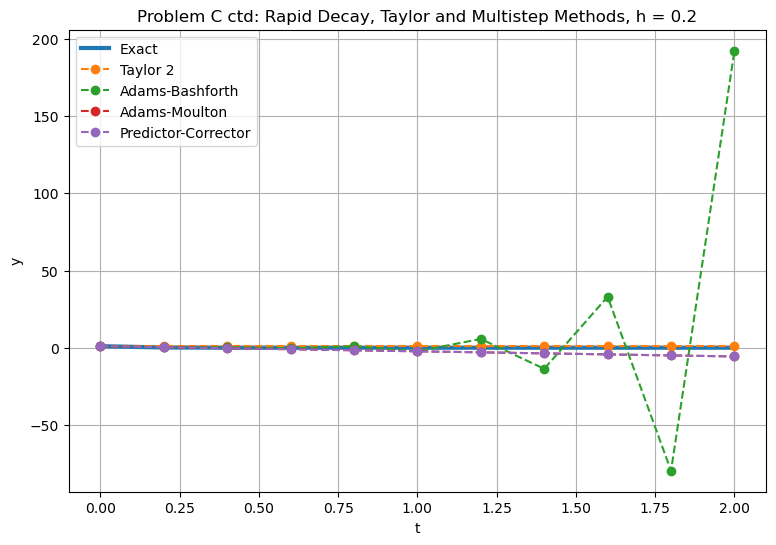

In [34]:
plt.figure(figsize=(9,6))

plt.plot(t_eu_C, exactC(t_eu_C), label="Exact", linewidth=3)
plt.plot(t_tay_C, w_tay_C, "o--", label="Taylor 2")
plt.plot(t_ab_C, w_ab_C, "o--", label="Adams-Bashforth")
plt.plot(t_am_C, w_am_C, "o--", label="Adams-Moulton")
plt.plot(t_pc_C, w_pc_C, "o--", label="Predictor-Corrector")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Problem C ctd: Rapid Decay, Taylor and Multistep Methods, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

### Error Comparison

In [35]:
err_eu_C = np.abs(exactC(t_eu_C) - w_eu_C)
err_tay_C = np.abs(exactC(t_tay_C) - w_tay_C)
err_mid_C = np.abs(exactC(t_mid_C) - w_mid_C)
err_heun_C = np.abs(exactC(t_heun_C) - w_heun_C)
err_rk4_C = np.abs(exactC(t_rk4_C) - w_rk4_C)
err_ab_C = np.abs(exactC(t_ab_C) - w_ab_C)
err_am_C = np.abs(exactC(t_am_C) - w_am_C)
err_pc_C = np.abs(exactC(t_pc_C) - w_pc_C)

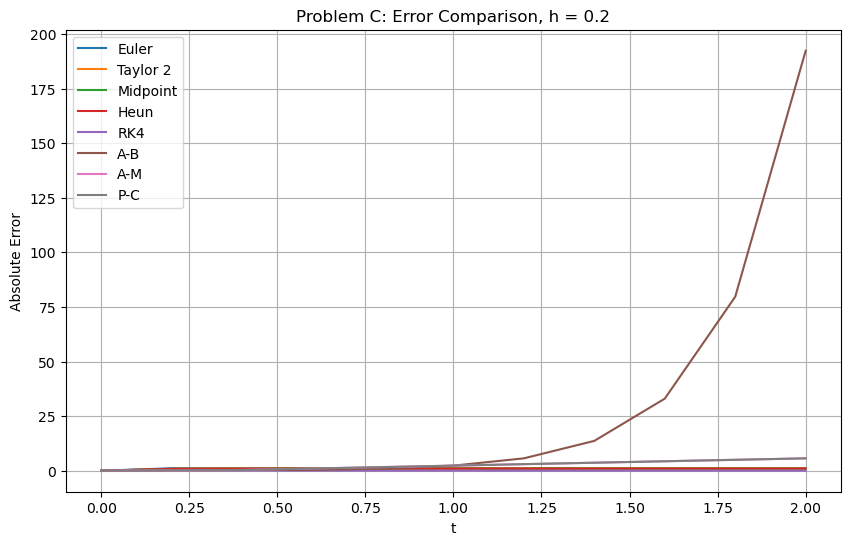

In [36]:
plt.figure(figsize=(10,6))

plt.plot(t_eu_C, err_eu_C, label="Euler")
plt.plot(t_tay_C, err_tay_C, label="Taylor 2")
plt.plot(t_mid_C, err_mid_C, label="Midpoint")
plt.plot(t_heun_C, err_heun_C, label="Heun")
plt.plot(t_rk4_C, err_rk4_C, label="RK4")
plt.plot(t_ab_C, err_ab_C, label="A-B")
plt.plot(t_am_C, err_am_C, label="A-M")
plt.plot(t_pc_C, err_pc_C, label="P-C")

plt.xlabel("t")
plt.ylabel("Absolute Error")
plt.title("Problem C: Error Comparison, h = 0.2")
plt.legend()
plt.grid(True)
plt.show()

**Max Error Table**

In [37]:
h_values = [0.2, 0.1, 0.05]

methods_C = [
    ("Euler", euler),
    ("Taylor", taylor2_C),
    ("Midpoint", midpoint),
    ("Heun", heun),
    ("RK4", rk4),
    ("A-B", adams_bashforth),
    ("A-M", adams_moulton),
    ("P-C", predictor_corrector)
]

print(f"{'Method':<22} {'h = 0.2':>15} {'h = 0.1':>15} {'h = 0.05':>15}")
print("-" * 70)

for method_name, method in methods_C:
    row = f"{method_name:<22}"

    for h in h_values:
        if method_name == "Taylor":
            t, w = method(t0_C, y0_C, T_C, h)
        else:
            t, w = method(fC, t0_C, y0_C, T_C, h)

        exact_values = exactC(t)
        error = np.abs(exact_values - w)
        max_err = np.max(error)

        row += f"{max_err:15.6e}"

    print(row)

Method                         h = 0.2         h = 0.1        h = 0.05
----------------------------------------------------------------------
Euler                    1.135335e+00   3.678794e-01   1.178794e-01
Taylor                   1.000000e+00   1.321206e-01   2.274556e-02
Midpoint                 1.000000e+00   1.321206e-01   2.274556e-02
Heun                     1.000000e+00   1.321206e-01   2.274556e-02
RK4                      1.979981e-01   7.120559e-03   2.914030e-04
A-B                      1.923333e+02   1.771647e-01   3.381327e-02
A-M                      5.666667e+00   1.619466e-02   4.738424e-03
P-C                      5.666667e+00   1.200996e-01   1.722806e-02


### Comparing Numerical Approximations & Abs Error: Euler, Adams-Bashforth, RK4

**Euler's Method**

In [38]:
print(f"{'t':<8}{'Exact':<15}{'Euler':<15}{'Abs Error':<15}")
print("-"*60)

for i in range(len(t_eu_C)):
    print(
        f"{t_eu_C[i]:<8.2f}"
        f"{exactC(t_eu_C)[i]:<15.6f}"
        f"{w_eu_C[i]:<15.6f}"
        f"{err_eu_C[i]:<15.6e}"
    )

t       Exact          Euler          Abs Error      
------------------------------------------------------------
0.00    1.000000       1.000000       0.000000e+00   
0.20    0.135335       -1.000000      1.135335e+00   
0.40    0.018316       1.000000       9.816844e-01   
0.60    0.002479       -1.000000      1.002479e+00   
0.80    0.000335       1.000000       9.996645e-01   
1.00    0.000045       -1.000000      1.000045e+00   
1.20    0.000006       1.000000       9.999939e-01   
1.40    0.000001       -1.000000      1.000001e+00   
1.60    0.000000       1.000000       9.999999e-01   
1.80    0.000000       -1.000000      1.000000e+00   
2.00    0.000000       1.000000       1.000000e+00   


**Adams-Bashforth Method**

In [39]:
print(f"{'t':<8}{'Exact':<15}{'A-B':<15}{'Absolute Error':<15}")
print("-"*60)

for i in range(len(t_ab_C)):
    print(
        f"{t_ab_C[i]:<8.2f}"
        f"{exactC(t_ab_C)[i]:<15.6f}"
        f"{w_ab_C[i]:<15.6f}"
        f"{err_ab_C[i]:<15.6e}"
    )

t       Exact          A-B            Absolute Error 
------------------------------------------------------------
0.00    1.000000       1.000000       0.000000e+00   
0.20    0.135335       0.333333       1.979981e-01   
0.40    0.018316       0.333333       3.150177e-01   
0.60    0.002479       -0.333333      3.358121e-01   
0.80    0.000335       1.000000       9.996645e-01   
1.00    0.000045       -2.333333      2.333379e+00   
1.20    0.000006       5.666667       5.666661e+00   
1.40    0.000001       -13.666667     1.366667e+01   
1.60    0.000000       33.000000      3.300000e+01   
1.80    0.000000       -79.666667     7.966667e+01   
2.00    0.000000       192.333333     1.923333e+02   


**RK4 Method**

In [40]:
print(f"{'t':<8}{'Exact':<15}{'RK4':<15}{'Absolute Error':<15}")
print("-"*60)

for i in range(len(t_rk4_C)):
    print(
        f"{t_rk4_C[i]:<8.2f}"
        f"{exactC(t_rk4_C)[i]:<15.6f}"
        f"{w_rk4_C[i]:<15.6f}"
        f"{err_rk4_C[i]:<15.6e}"
    )

t       Exact          RK4            Absolute Error 
------------------------------------------------------------
0.00    1.000000       1.000000       0.000000e+00   
0.20    0.135335       0.333333       1.979981e-01   
0.40    0.018316       0.111111       9.279547e-02   
0.60    0.002479       0.037037       3.455828e-02   
0.80    0.000335       0.012346       1.201022e-02   
1.00    0.000045       0.004115       4.069826e-03   
1.20    0.000006       0.001372       1.365598e-03   
1.40    0.000001       0.000457       4.564158e-04   
1.60    0.000000       0.000152       1.523033e-04   
1.80    0.000000       0.000051       5.079003e-05   
2.00    0.000000       0.000017       1.693303e-05   


#### Discussion of Results
The problem selected in this case certainly demonstrates a wider variety of behaviors among the various methods that have been considered in this project. Euler's specifically shows significant oscillation between positive and negative values; the update of $w_{n+1} = (1-10h)w_n$ returns negative for $h=0.2$. Adams-Bashforth also demonstrates instability in the second plot, driven by oscillations and divergence caused by sensitivity to step size and accumulation of prior local errors. As demonstrated by the mesh point comparison table and its inclusion in the final absolute error comparison table, it's error is the largest among all the methods and grows by relatively significant factors over time. Other second-order methods like Taylor, Midpoint and Heun are hindered by larger step sizes. RK4, while not exact here, still performs the best, again reflecting its highest-order accuracy and stability. 

## Conclusion

The goal of the project was to investigate the performance of several numerical methods in solving behaviorally-varied ordinary differential equations. Problem A, which tested the methods against a simpler, near linear solution, highlighting which functions exhibited the most immediate accuracy or issues with approximation. Euler's and RK4 emerged as the least and most accurate, respectively. Problem B further illustrated the variables at play in numerical approximation, utilizing an exponential solution to highlight the effects of error amplification/accumulation in a rapid growth scenario. A further difference was demonstrated between the higher and lower order methods as Euler's, and to a lesser degree, the second-order methods struggled to limit deviation. The rapid decay solution in problem C perhaps most distinctly highlighted the differences between methods; Euler's exhibited significant oscillation while Adams-Bashforth displayed oscillation as well as catastrophic deviation. Taken altogether, these experiments reaffirm several theoretical principles of numerical analysis. In each case, decreasing step size improved accuracy, in some cases rather rapidly. Higher-order, more computationally advanced methods demonstrated a more advanced ability at reducing location truncation error and avoiding significant deviation. Stability, as we saw in the case of Adams-Bashforth's conditional stability, is also essential for producing reasonable approximations and convergence. The selection of appropriate numerical methods is thus a matter of balancing computational cost, consistency, and stability for the problem being considered. A more sophisticated method like RK4 while consistently most accurate may not be necessary in simpler problems like A, and quite necessary in approximating more behaviorally challenging solutions. 